# 11 — What an edit did

A cache pays for itself the afternoon you edit one node twenty times and the
expensive one underneath is never asked again. It also opens a question that has
no good answer today: **did I just invalidate the encoder, or only the head?**
You find out by running and watching which nodes take time.

You do not have to. A name here is a hash of the **recipe** and not of the data —
only the graph's input is hashed by content, and from there down they are hashes
of hashes — so every name is knowable with nothing executed. Two versions of one
graph name a node differently *exactly when* its recipe changed, and comparing
two sets of names says what an edit did.

    from soma_next import foreseen

    foreseen.names(g)                       # what each answer will be called
    foreseen.unneeded(g, x, store=store)    # what would not have to run
    foreseen.changes(before, after)         # what the edit did

This notebook is one afternoon of edits, and it is also where a hole in the
first draft of `changes` turned up — the section near the end that says so.

In [1]:
import importlib
import pathlib
import sys
import tempfile
import time

from soma_next import Graph, Node, Store, foreseen

## The graph, and the half of it worth keeping

`Encoder` is the one that costs. It is **settled** — `.frozen()` says its state
does not change while the graph runs — and `.cached()` says keep its answer. What
feeds it is frozen too, and that is refused rather than warned about: an answer
is only worth a name if nothing above it can change under it. `Head` is the cheap
end, and the one being fiddled with twenty times an afternoon.

Nothing here is a special kind of node. The `sleep` is what a real encoder costs,
in miniature.

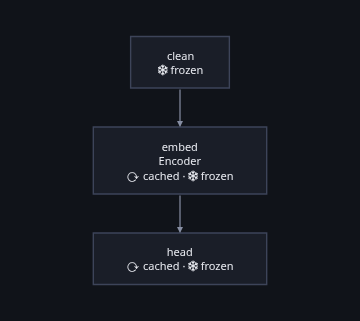

In [2]:
class Clean(Node):
    """Text in, the length of each word out."""

    def forward(self, text, ctx):
        return [len(word) for word in text.split()]


class Encoder(Node):
    """The expensive, settled half. Counts what it was really asked."""

    def __init__(self):
        self.calls = 0

    def forward(self, lengths, ctx):
        self.calls += 1
        time.sleep(0.15)
        return sum(lengths) / len(lengths)


class Head(Node):
    """How spammy that is, on a scale nobody agrees on."""

    def forward(self, mean, ctx):
        return min(1.0, mean / 6)


def spam_filter(head=Head, salt=None):
    """The graph, and the encoder inside it so its calls can be counted."""
    encoder = Encoder()
    g = Graph.somatize(
        Clean().named("clean").frozen()
        >> encoder.named("embed").frozen().cached()
        >> head().named("head").frozen().cached(salt=salt)
    )
    return g, encoder


g, encoder = spam_filter()
g.figure()

## The names, before anything has run

Nothing was executed to answer this, and there is no store: a store is only where
the hash function comes from, so `foreseen.names(g)` opens a temporary one and
throws it away. These are the names the run below will keep things under.

In [3]:
foreseen.names(g)

{'clean': 'sha256:4352bd047b4ff3f87685d5ec6c77cf1196a7821529712dbf783065b07f9424b0',
 'embed': 'sha256:cc7a2a272b67456b2b58a9d1f518a40de4ec12038d92224ae9934e280768e29e',
 'head': 'sha256:765575ba47bfe94ff9835695d285294d71f1baa0988cfa330623ae437a5d510b'}

## And then the run

Twice, against a real store. The second one costs nothing and the encoder is
never asked — which is the point of the cache and not of this notebook.

In [4]:
store = Store(tempfile.mkdtemp())
text = "the quick brown fox jumps over the lazy dog and then goes home"

for attempt in (1, 2):
    started = time.perf_counter()
    answer = g.forward(text, store=store)
    print(f"{attempt}: {answer:.3f}  in {time.perf_counter() - started:.3f}s")

print("the encoder was asked", encoder.calls, "time")

1: 0.641  in 0.151s
2: 0.641  in 0.000s
the encoder was asked 1 time


## What would not have to run at all

The other half of the same pass, and the only question here whose answer depends
on what is *in* the store. The head's answer is already there, so nothing that
only feeds it has to run — which is CU25, asked without running.

In [5]:
foreseen.unneeded(g, text, store=store)

['clean', 'embed']

## I changed the head

A stricter threshold, which here is another class. Its identity is part of its
name, so the name moves — and nothing above it moves, which is the whole reason
the encoder is worth keeping.

In [6]:
class Stricter(Node):
    """The same job, a different mind about it."""

    def forward(self, mean, ctx):
        return min(1.0, mean / 4)


after, _ = spam_filter(head=Stricter)
foreseen.changes(g, after)

{'embed': ['UNVERSIONED'], 'head': ['CHANGED']}

## The half a notebook cannot answer

`head` is answered. `embed` says `UNVERSIONED`, and that is not a hedge — it is
the honest state of things in here.

The fingerprint of the code is **deliberately not in a key**: a cosmetic refactor
must not invalidate half a store in silence, so it is kept beside the value and
compared on a hit. The cost is that editing the body of a `forward` renames
nothing, which is why `changes` looks at the fingerprint separately.

And there is no fingerprint here, because **a class defined in a cell has no
source to read**. Every node in this notebook is defined in a cell:

In [7]:
g.fingerprints()

{}

The first draft of `changes` treated that as no opinion and said nothing about
it. Writing this notebook is what showed what that means: in the one place where
the question gets asked most, an afternoon of edits came back as `{}` — *nothing
to report*. So the absence is a finding, and the answer to it is the thing you
were going to do anyway.

## Put the node in a file, and the other half arrives

Which is where it lives in a real project. `nodes.py` here is written, imported,
**edited**, and reloaded — exactly what saving a file and re-running a cell does.

In [8]:
where = pathlib.Path(tempfile.mkdtemp())
sys.path.insert(0, str(where))

MODULE = """from soma_next import Node


class Clean(Node):
    def forward(self, text, ctx):
        return [len(word) for word in text.split()]


class Encoder(Node):
    def forward(self, lengths, ctx):
        return {encoder}


class Head(Node):
    def forward(self, mean, ctx):
        return min(1.0, mean / 6)
"""

MEAN = "sum(lengths) / len(lengths)"
ROOT_MEAN_SQUARE = "(sum(one * one for one in lengths) / len(lengths)) ** 0.5"

(where / "nodes.py").write_text(MODULE.format(encoder=MEAN))
import nodes


def filed(salt=None):
    """The same graph, with the nodes taken from the file as it stands now."""
    return Graph.somatize(
        nodes.Clean().named("clean").frozen()
        >> nodes.Encoder().named("embed").frozen().cached()
        >> nodes.Head().named("head").frozen().cached(salt=salt)
    )


monday = filed()
monday.fingerprints()

{'embed': 'e9af4168', 'head': '05c97a40'}

In [9]:
(where / "nodes.py").write_text(MODULE.format(encoder=ROOT_MEAN_SQUARE))
importlib.reload(nodes)
tuesday = filed()

foreseen.changes(monday, tuesday)

{'embed': ['STALE'], 'head': ['SUSPECT']}

## `STALE`, and everything it reaches

`STALE` is the finding this exists for, and it is one sentence: **its name did
not move and its code did**. The store will hand back Monday's number for
Tuesday's code, and nothing in the key says so.

`SUSPECT` is the other half, and it is why this is not one finding but two. The
encoder hits, so the head goes on being fed the answer the old code gave —
whatever became of the head's own name. Salt the head as well and it recomputes,
honestly, from a stale input:

In [10]:
foreseen.changes(monday, filed(salt="v2"))

{'embed': ['STALE'], 'head': ['SALTED', 'SUSPECT']}

That output is why `changes` answers `{node: [finding, ...]}` and not one bucket
per node. `head` recomputes **and** recomputes from a stale answer; both are
true, and a shape that could only carry one of them would have carried the
reassuring one.

## The answer `STALE` is asking for

Bump the salt on the node whose code you edited. Then the name moves, the store
misses, and the new code runs — which is the same edit, answered:

In [11]:
salted = Graph.somatize(
    nodes.Clean().named("clean").frozen()
    >> nodes.Encoder().named("embed").frozen().cached(salt="rms")
    >> nodes.Head().named("head").frozen().cached()
)

foreseen.changes(monday, salted)

{'embed': ['SALTED'], 'head': ['DOWNSTREAM']}

`SALTED` where the edit is, `DOWNSTREAM` for what inherited it. On a graph of
forty nodes that distinction is the whole readability of the answer: one of them
is what you did and the rest is what it reached.

## And what it was built with

`CHANGED` is the shape, and the shape is more than the class. `Sized(512)` and
`Sized(64)` are one class, one identity and two different answers — before what a
node was built with went into its key they shared a name in the store, and the
second one was handed the first one's with no error and no warning.

What is captured is what was passed to `__init__`, and **not** what the object
turns out to be holding. A node that counts its calls, caches a client on first
use or moves a tensor onto a device has attributes that move *while the graph
runs*, and a key made of those would rename a node nobody touched. The second
line below is that, as a question with a yes: `wide` has run and its counter has
moved, and it is still called what a fresh one is called.

In [12]:
class Sized(Node):
    def __init__(self, dim):
        self.dim = dim
        self.calls = 0

    def forward(self, lengths, ctx):
        self.calls += 1
        return sum(lengths) / self.dim


def sized(dim):
    return Graph.somatize(
        Clean().named("clean").frozen()
        >> Sized(dim).named("embed").frozen().cached()
        >> Head().named("head").frozen().cached()
    )


wide = sized(512)
wide.forward(text, store=store)          # it runs, so its counter moves

print("built differently: ", foreseen.changes(wide, sized(64)))
print("and after running:  ", foreseen.names(wide) == foreseen.names(sized(512)))

built differently:  {'embed': ['CHANGED'], 'head': ['DOWNSTREAM']}
and after running:   True


## Three ways a name moves, and only one of them is code

`SALTED` and not `CHANGED`, because those are not the same news. A name moves for
three reasons and they are told apart:

- `CHANGED` — its **shape**: another class, or somebody else feeding it.
- `RESETTLED` — frozen at another state: other weights, another dataset version.
- `SALTED` — the salt moved.

Two questions get asked of this answer and they want different halves of it.
*Does my cache still hold* is all three at once — a node frozen at another
checkpoint really does produce another answer, and the name moving is the cache
being right. *Did the code change* is `CHANGED` alone: **weights belong to a
version, they are not a version**, and the same architecture trained again is the
same thing trained again.

Here is the middle one on its own — the same graph, settled at two checkpoints.
`freeze` here is the primitive `soma_next.torch.freeze` ends up calling once it
has hashed the weights:

In [13]:
monday_weights, tuesday_weights = filed(), filed()
monday_weights.freeze("embed", "sha256:monday")
tuesday_weights.freeze("embed", "sha256:tuesday")

foreseen.changes(monday_weights, tuesday_weights)

{'embed': ['RESETTLED'], 'head': ['DOWNSTREAM']}

## Two graphs, or two snapshots

Everything above compares two **live** graphs, which is what an afternoon looks
like. Two commits do not: two versions of one module cannot coexist in an
interpreter. So `changes` takes either a graph or a `snapshot` of one — plain
JSON with the names already worked out, which is what you keep beside a commit
and compare against code that is no longer here.

In [14]:
import json

kept = json.loads(json.dumps(foreseen.snapshot(monday)))
print(sorted(kept))

foreseen.changes(kept, tuesday)

['declared', 'edges', 'fingerprints', 'kept', 'names', 'salt', 'shape', 'state']


{'embed': ['STALE'], 'head': ['SUSPECT']}

## What it costs

Nothing. `changes` never reads or writes a store, and it does not need the input
either: every key on both sides carries the same hash of it, so which input it is
cancels out of every comparison.

In [15]:
big = "spam " * 400_000

started = time.perf_counter()
nothing = foreseen.changes(monday, tuesday)
without = time.perf_counter() - started

started = time.perf_counter()
real = foreseen.changes(monday, tuesday, big)
with_it = time.perf_counter() - started

print(f"with no input at all: {without * 1000:.1f} ms")
print(f"with 2 MB of input:   {with_it * 1000:.1f} ms")
print("the same answer:", nothing == real)

with no input at all: 1.7 ms
with 2 MB of input:   40.4 ms
the same answer: True


The toll is paid **twice**, once per graph, for an answer that does not depend
on it at all. So the cheap call is also the correct one, and the 121 ms of
weighing a batch that notebook 10 measured is not paid to ask a question about
names.

## What is not in it

- **The figure.** `soma_next.health.overlaid` puts findings on a graph, and its
  channel is health: the outline turns red and red means ill. A node that changed
  is not ill, so marking one would need a channel of its own.
- **An edit above a cached node.** A version is recorded only for what is kept —
  see `monday.fingerprints()` above, where `clean` is missing — because parsing
  an AST for a node nobody remembers anything about would be paid by everyone who
  declares a graph. So editing `Clean` up there moves nothing and `embed` goes on
  hitting — and the runtime has the same blind spot, for the same
  reason: it compares a fingerprint on a hit, and there is no hit to compare on.